# 02-Document Parsing & Chunking Math

In Lesson 01, we established the physics of Retrieval-Augmented Generation (RAG). We proved that injecting external knowledge ($z$) into the LLM's prompt forces the network to ground its answers in reality, suppressing hallucinations.

However, Enterprise knowledge does not exist as neat, single-sentence strings. It exists as 500-page PDF reports, massive SQL dumps, and endless Confluence pages.
If we feed a 500-page PDF directly into our system, we hit two fatal mathematical walls:

1. **The Embedding Wall**: The Bi-Encoders used to convert text into Dense Vectors (like `text-embedding-3-small` or `all-MiniLM-L6-v2`) have a strict absolute maximum context window, typically exactly **512 tokens**. If you pass 10,000 tokens, the matrix multiplication physically truncates and deletes the remaining 9,488 tokens.
2. **The Retrieval Dilution (Lost in the Middle)**: Even if the LLM has a 128,000-token context window, forcing the Self-Attention mechanism to scan a massive document to answer a tiny question dilutes the Attention weights. The model will likely miss the needle in the haystack.

To solve this, we must shatter massive documents into mathematically precise fragments called **Chunks**.

Let's set up our Python environment to engineer the calculus of semantic splitting.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import numpy as np

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Text Segmentation Environment Ready.")

✅ Systems Architecture & Text Segmentation Environment Ready.


# 1. The Mathematics of the Rolling Window

To chunk a document, we cannot simply chop it into pieces of exactly 512 tokens.
If we do, the 512th token might be the word *"New"*, and the 513th token might be *"York"*. We have mathematically severed a single semantic entity into two separate vectors. When the user asks about "New York", neither Chunk A nor Chunk B will have a high enough Cosine Similarity to be retrieved.

To preserve semantic boundaries, we use a **Rolling Window with Overlap**.

Let $T = [t_1, t_2, \dots, t_N]$ be a sequence of tokens in a document.
We define two hyperparameters:

* **Chunk Size ($L_c$)**: The maximum number of tokens per chunk (e.g., $512$).
* **Overlap ($L_o$)**: The number of tokens shared between adjacent chunks (e.g., $50$).

The starting index for any chunk $i$ is determined by the **Stride** ($S$), where $S = L_c - L_o$.
The exact token span for chunk $C_i$ is:


$$C_i = T[i \cdot S : i \cdot S + L_c]$$

By overlapping the chunks, we mathematically guarantee that any concept bridging the boundary of Chunk A is fully contained within the beginning of Chunk B.

# 2. Recursive Character Splitting

Counting raw tokens is dangerous because it ignores human grammar. If we split strictly by a math formula, we will cut a sentence in half.

The Enterprise standard is **Recursive Character Splitting**. We attempt to split the document by the largest semantic structures first, recursively falling back to smaller structures only if the chunk exceeds $L_c$:

1. **Paragraphs (`\n\n`)**: We try to keep paragraphs intact. If a paragraph is smaller than $L_c$, it becomes a chunk.
2. **Sentences (`. `)**: If a single massive paragraph exceeds $L_c$, we recurse and split it by sentences.
3. **Words (` `)**: If a single massive run-on sentence exceeds $L_c$, we split by spaces.
4. **Characters**: If a single massive unspaced word exceeds $L_c$ (e.g., genomic sequencing), we forcefully chop it.

# 3. Architecting the Chunking Engine

Let's build a deterministic rolling-window chunker in Python. We will define a simulated enterprise document, establish our $L_c$ and $L_o$ parameters, and execute the splitting logic.

In [2]:
# --- ✂️ The Text Segmentation Engine ---

def rolling_window_chunker(text: str, chunk_size: int, overlap: int):
    """
    Splits text using a mathematical sliding window approach.
    (Note: For clarity, this simulation chunks by CHARACTERS/WORDS, 
    but in production, you MUST chunk by TOKENS using a library like tiktoken).
    """
    words = text.split(" ")
    chunks = []
    
    # Calculate the Stride (S)
    stride = chunk_size - overlap
    
    # Execute the boundary calculus
    for i in range(0, len(words), stride):
        # Extract the specific slice of words
        chunk_slice = words[i : i + chunk_size]
        
        # Join back into a string
        chunk_text = " ".join(chunk_slice)
        chunks.append(chunk_text)
        
        # Break if we have reached the absolute end of the document
        if i + chunk_size >= len(words):
            break
            
    return chunks

# 1. The Raw Document
enterprise_document = (
    "Project Quantum is a highly classified initiative. "
    "We are building a massive GPU cluster in Iceland. "
    "The cooling systems will utilize natural geothermal energy. "
    "Sarah Jenkins is leading the engineering team. "
    "The estimated budget is roughly two billion dollars. "
    "Launch is scheduled for Q4 2026."
)

# 2. Define Hyperparameters
L_c = 12 # Chunk Size (Words)
L_o = 4  # Overlap (Words)

print(f"--- 📄 Processing Document (Total Words: {len(enterprise_document.split())}) ---")
print(f"Hyperparameters: Chunk Size = {L_c}, Overlap = {L_o}, Stride = {L_c - L_o}")

# 3. Execute Segmentation
document_chunks = rolling_window_chunker(enterprise_document, L_c, L_o)

print("\n--- 🧱 Generated Chunks ---")
for idx, chunk in enumerate(document_chunks):
    print(f"Chunk {idx}: '{chunk}'")

print("\n--- 💡 Engineering Insight ---")
print("Notice the Overlap! Chunk 0 ends with 'systems will utilize natural'. Chunk 1 starts with 'cooling systems will utilize natural geothermal'. Because of the 4-word overlap, the semantic concept of 'natural geothermal cooling systems' is perfectly preserved in Chunk 1, even though it fell on the exact mathematical boundary of Chunk 0.")

--- 📄 Processing Document (Total Words: 45) ---
Hyperparameters: Chunk Size = 12, Overlap = 4, Stride = 8

--- 🧱 Generated Chunks ---
Chunk 0: 'Project Quantum is a highly classified initiative. We are building a massive'
Chunk 1: 'are building a massive GPU cluster in Iceland. The cooling systems will'
Chunk 2: 'The cooling systems will utilize natural geothermal energy. Sarah Jenkins is leading'
Chunk 3: 'Sarah Jenkins is leading the engineering team. The estimated budget is roughly'
Chunk 4: 'estimated budget is roughly two billion dollars. Launch is scheduled for Q4'
Chunk 5: 'is scheduled for Q4 2026.'

--- 💡 Engineering Insight ---
Notice the Overlap! Chunk 0 ends with 'systems will utilize natural'. Chunk 1 starts with 'cooling systems will utilize natural geothermal'. Because of the 4-word overlap, the semantic concept of 'natural geothermal cooling systems' is perfectly preserved in Chunk 1, even though it fell on the exact mathematical boundary of Chunk 0.


# 4. Visualizing the Overlap Geometry

To mathematically prove why the overlapping stride prevents information loss, we will visualize the sequence geometry using Matplotlib. We will map the document as a 1D timeline of tokens and plot the boundary boxes of the chunks.

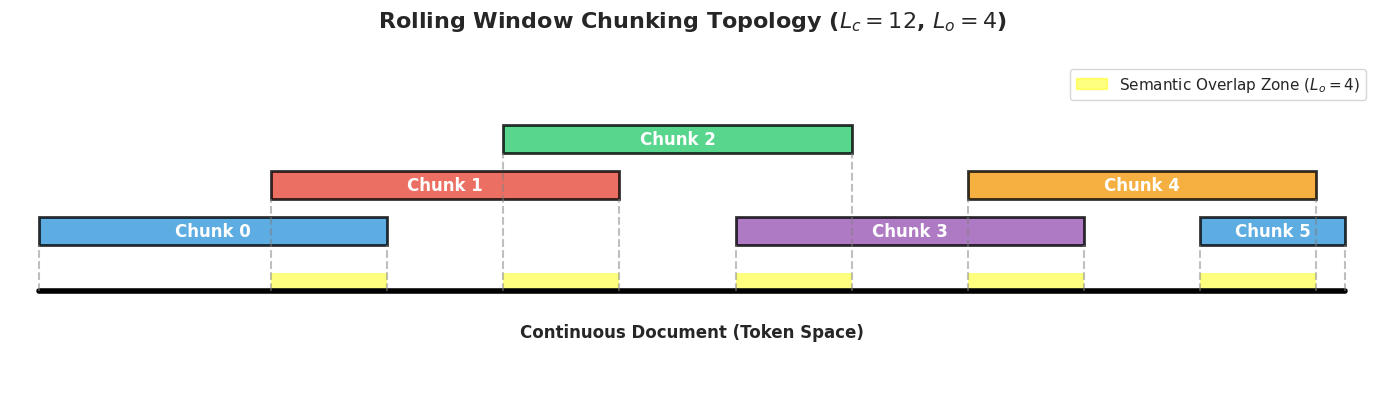

In [3]:
# Visualizing Chunk Overlap Physics
fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle(f"Rolling Window Chunking Topology ($L_c = {L_c}$, $L_o = {L_o}$)", fontsize=16, fontweight='bold')

ax.axis('off')

total_words = len(enterprise_document.split(" "))
stride = L_c - L_o

# 1. Draw the Base Document Timeline
ax.plot([0, total_words], [0, 0], color='black', linewidth=4)
ax.text(total_words/2, -0.5, "Continuous Document (Token Space)", ha='center', fontweight='bold', fontsize=12)

# 2. Draw the Chunks
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']
y_offsets = [0.5, 1.0, 1.5, 0.5, 1.0] # Staggered Y heights for visual clarity

for i, chunk in enumerate(document_chunks):
    start_idx = i * stride
    end_idx = min(start_idx + L_c, total_words)
    
    y = y_offsets[i % len(y_offsets)]
    color = colors[i % len(colors)]
    
    # Draw the Chunk Boundary Box
    rect = patches.Rectangle((start_idx, y), end_idx - start_idx, 0.3, 
                             linewidth=2, edgecolor='black', facecolor=color, alpha=0.8)
    ax.add_patch(rect)
    ax.text(start_idx + (end_idx - start_idx)/2, y + 0.15, f"Chunk {i}", 
            ha='center', va='center', color='white', fontweight='bold')
    
    # Draw projection lines down to the base timeline
    ax.plot([start_idx, start_idx], [0, y], color='gray', linestyle='--', alpha=0.5)
    ax.plot([end_idx, end_idx], [0, y], color='gray', linestyle='--', alpha=0.5)

    # Highlight the Overlap
    if i > 0:
        overlap_start = start_idx
        overlap_end = start_idx + L_o
        overlap_rect = patches.Rectangle((overlap_start, 0), overlap_end - overlap_start, 0.2, 
                                         linewidth=0, facecolor='yellow', alpha=0.5)
        ax.add_patch(overlap_rect)

# Add Legend for the Yellow Overlap Zones
overlap_patch = patches.Patch(color='yellow', alpha=0.5, label=f'Semantic Overlap Zone ($L_o = {L_o}$)')
ax.legend(handles=[overlap_patch], loc='upper right')

plt.xlim(-1, total_words + 1)
plt.ylim(-1, 2.5)
plt.tight_layout()
plt.show()


## Real-World Use Case or Analogy:

Think of Document Chunking like **Taking Panoramic Photos of a Landscape**:

* **The Problem**: You want to capture an entire 360-degree mountain range (The Document), but your camera lens (The Embedding Model Context Window) can only see 60 degrees at a time.
* **Zero Overlap (The Error)**: You take a photo, turn exactly 60 degrees, and take the next photo. Later, when you look at the photos, you realize a beautiful waterfall was split perfectly down the middle. Half the waterfall is on the right edge of Photo A, and half is on the left edge of Photo B. The image is ruined.
* **Rolling Window Chunking**: You take a photo. You turn 45 degrees (The Stride), leaving a 15-degree overlap ($L_o$). You take the next photo. Now, the entire waterfall is perfectly framed in the center of Photo B. The semantic entity (the waterfall) survived the segmentation.